### Results Analysis: Downstream Regressor Selection

This notebook analyzes the results of the `model_comparison.ipynb` across seeds.
The goal is to decide which downstream regression model should be selected.

The main question answered by this notebook is:

> Considering different feature families and different seeds, which regression model has the best overall performance?

To answer this question, we aggregate the results across feature families and seeds, then compare the models using:

- **MAE**
- **RMSE**
- **R²**

Based on the analysis below, the **MLP** is selected as the downstream regressor.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    font="sans-serif",
    font_scale=1.0,
    rc={
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.titlesize": 9,
    },
)

RESULTS_BASE_DIR = Path(f"../../results/model_comparison")
SEEDS = [13, 23, 37]

#### Load Metrics from All Seeds

Each seed run produces a `summary.csv` file with the evaluation metrics for all combinations of:

- feature family;
- downstream model;
- data split.

In [3]:
all_metrics = []

for seed in SEEDS:
    seed_dir = RESULTS_BASE_DIR / f"seed_{seed}"
    summary_path = seed_dir / "summary.csv"
    
    if summary_path.exists():
        df = pd.read_csv(summary_path)
        # Summary does not have this column
        df["seed"] = seed 
        all_metrics.append(df)
    else:
        print(f"Warning: {summary_path} not found.")

if not all_metrics:
    raise FileNotFoundError("No summary.csv files found. Make sure you ran the pipeline for at least one seed.")

results_df = pd.concat(all_metrics, ignore_index=True)

print(f"Loaded {len(results_df)} rows from {results_df['seed'].nunique()} seeds.")
print("Models:", results_df["model"].unique())
print("Families:", results_df["family"].unique())
print("Splits:", results_df["split"].unique())

Loaded 144 rows from 3 seeds.
Models: <StringArray>
['RF', 'XGB', 'MLP']
Length: 3, dtype: str
Families: <StringArray>
[           'ad_lstm_wl_delta',             'ad_xgb_wl_delta',
 'dd_lstm_shortest_path_delta',             'dd_xgb_wl_delta']
Length: 4, dtype: str
Splits: <StringArray>
['train', 'validation', 'test-interpolation', 'test-extrapolation']
Length: 4, dtype: str


#### Aggregate Results (Mean ± Std)

The goal is to select the best downstream regressor, not the best individual feature-family/model combination.

All results from the same model are grouped together across:
```text
    feature families × seeds
```

The mean indicates the average performance.
The standard deviation indicates how much the performance varies across feature families and seeds.

<Figure size 4200x3000 with 0 Axes>

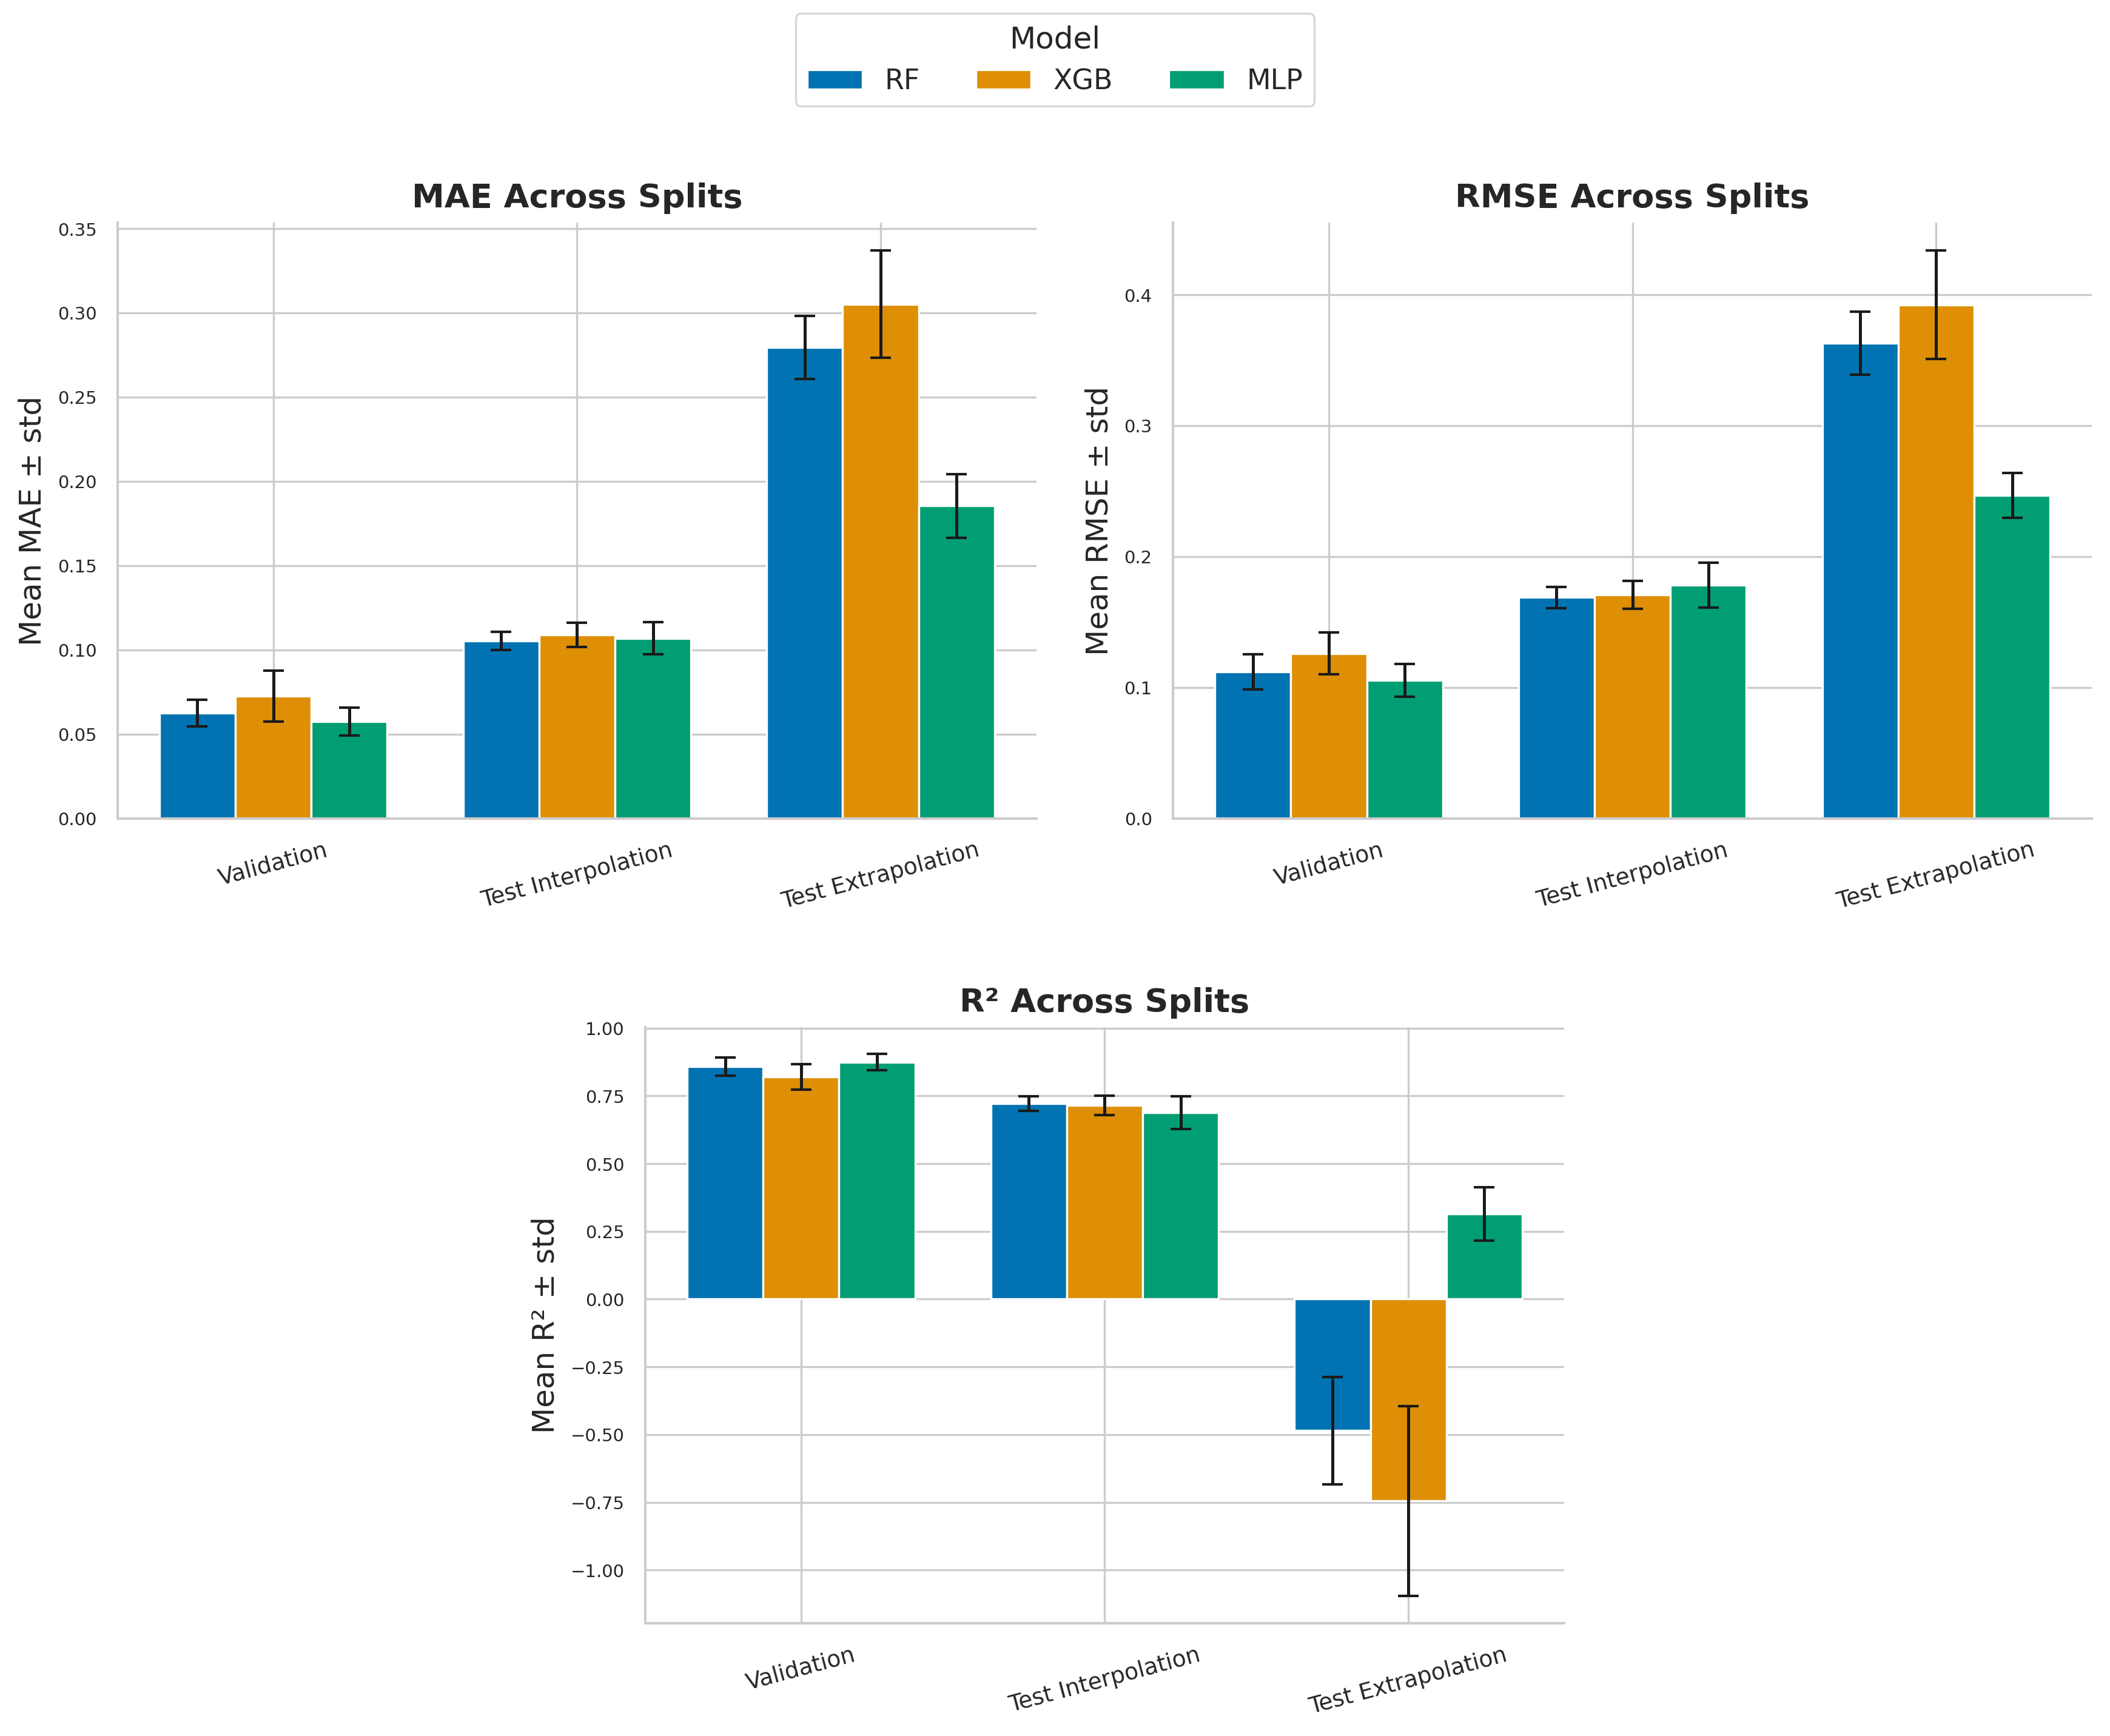

<Figure size 4200x3000 with 0 Axes>

<Figure size 4200x3000 with 0 Axes>

<Figure size 4200x3000 with 0 Axes>

In [11]:
eval_df = results_df[results_df["split"].isin(["validation", "test-interpolation", "test-extrapolation"])].copy()

agg_model_df = (
    eval_df
    .groupby(["model", "split"])[["MAE", "RMSE", "R2"]]
    .agg(["mean", "std"])
    .reset_index()
)
agg_model_df['split'] = agg_model_df['split'].str.replace('test-', 'Test ').str.title()

agg_model_df.columns = [
    "model", "split",
    "MAE_mean", "MAE_std",
    "RMSE_mean", "RMSE_std",
    "R2_mean", "R2_std"
]

plot_splits_df = agg_model_df.copy()

split_order = ["Validation", "Test Interpolation", "Test Extrapolation"]
model_order = ["RF", "XGB", "MLP"]

plot_splits_df["split"] = pd.Categorical(
    plot_splits_df["split"],
    categories=split_order,
    ordered=True
)

plot_splits_df["model"] = pd.Categorical(
    plot_splits_df["model"],
    categories=model_order,
    ordered=True
)

plot_splits_df = plot_splits_df.sort_values(["split", "model"])

x = np.arange(len(split_order))
width = 0.25

def plot_metric(ax, metric, title, ylabel):
    for i, model in enumerate(model_order):
        model_df = (
            plot_splits_df[plot_splits_df["model"] == model]
            .set_index("split")
            .loc[split_order]
            .reset_index()
        )

        positions = x + (i - 1) * width

        ax.bar(
            positions,
            model_df[f"{metric}_mean"],
            width,
            yerr=model_df[f"{metric}_std"],
            capsize=4,
            label=model
        )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(split_order, rotation=15, fontsize=9)

    fig = plt.figure(figsize=(14, 10))

fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(2, 4, height_ratios=[1, 1], hspace=0.35, wspace=0.35)

fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(2, 4, height_ratios=[1, 1], hspace=0.35, wspace=0.35)

ax_mae = fig.add_subplot(gs[0, 0:2])
ax_rmse = fig.add_subplot(gs[0, 2:4])
ax_r2 = fig.add_subplot(gs[1, 1:3])

plot_metric(ax_mae, metric="MAE", title="MAE Across Splits", ylabel="Mean MAE ± std")

plot_metric(ax_rmse, metric="RMSE", title="RMSE Across Splits", ylabel="Mean RMSE ± std")

plot_metric(ax_r2, metric="R2", title="R² Across Splits", ylabel="Mean R² ± std")

handles, labels = ax_mae.get_legend_handles_labels()

fig.legend(handles, labels, title="Model", loc="upper center", ncol=3, fontsize=11, title_fontsize=12, frameon=True)

plt.savefig(RESULTS_BASE_DIR / "metrics_across_splits_by_model.png", dpi=150, bbox_inches="tight")

plt.show()

#### Rank Models on Test-Extrapolation

The `test-extrapolation` split is used as the primary criterion for model selection because it represents the most difficult generalization setting.

In [5]:
ranking_extrapolation = (
    agg_model_df[agg_model_df["split"] == "test-extrapolation"]
    .sort_values(
        ["MAE_mean", "RMSE_mean", "R2_mean"],
        ascending=[True, True, False]
    )
)

ranking_interpolation = (
    agg_model_df[agg_model_df["split"] == "test-interpolation"]
    .sort_values(
        ["MAE_mean", "RMSE_mean", "R2_mean"],
        ascending=[True, True, False]
    )
)

ranking_extrapolation

,model,split,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std


In [6]:
ranking_interpolation

,model,split,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std


#### Count Model Wins by MAE

To check consistency, we count how many times each model obtains the best MAE for each:

```text
family × seed × split
```

For each split, exists 12 wins opportunity (4 families * 3 seeds)

In [7]:
wins_mae = (
    eval_df
    .sort_values("MAE", ascending=True)
    .groupby(["family", "seed", "split"])
    .first()
    .reset_index()
)

win_counts_mae = (
    wins_mae
    .groupby(["split", "model"])
    .size()
    .reset_index(name="MAE_wins")
    .sort_values(["split", "MAE_wins"], ascending=[True, False])
)

win_counts_mae

,split,model,MAE_wins
0,test-extrapolation,MLP,12
1,test-interpolation,MLP,4
2,test-interpolation,RF,4
3,test-interpolation,XGB,4
4,validation,MLP,9
5,validation,RF,3


#### Count Model Wins by RMSE

This is the same consistency check as above, but using RMSE instead of MAE

In [8]:
wins_rmse = (
    eval_df
    .sort_values("RMSE", ascending=True)
    .groupby(["family", "seed", "split"])
    .first()
    .reset_index()
)

win_counts_rmse = (
    wins_rmse
    .groupby(["split", "model"])
    .size()
    .reset_index(name="RMSE_wins")
    .sort_values(["split", "RMSE_wins"], ascending=[True, False])
)

win_counts_rmse

,split,model,RMSE_wins
0,test-extrapolation,MLP,12
1,test-interpolation,MLP,4
2,test-interpolation,RF,4
3,test-interpolation,XGB,4
4,validation,MLP,8
5,validation,RF,4


#### Feature family that gives the MLP the lowest MAE/RMSE and highest R²

In [9]:
mlp_df = eval_df[eval_df["model"] == "MLP"].copy()

agg_mlp_family = (
    mlp_df
    .groupby(["family", "split"])[["MAE", "RMSE", "R2"]]
    .agg(["mean", "std"])
    .reset_index()
)

agg_mlp_family.columns = [
    "family", "split",
    "MAE_mean", "MAE_std",
    "RMSE_mean", "RMSE_std",
    "R2_mean", "R2_std"
]

ranking_mlp_extrapolation = (
    agg_mlp_family[agg_mlp_family["split"] == "test-extrapolation"]
    .sort_values(
        ["MAE_mean", "RMSE_mean", "R2_mean"],
        ascending=[True, True, False]
    )
)

ranking_mlp_extrapolation

,family,split,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
3,ad_xgb_wl_delta,test-extrapolation,0.171275,0.006508,0.238664,0.021602,0.357444,0.118665
6,dd_lstm_shortest_path_delta,test-extrapolation,0.175420,0.002859,0.244828,0.010894,0.326610,0.059085
9,dd_xgb_wl_delta,test-extrapolation,0.194485,0.011984,0.247626,0.011716,0.311011,0.065239
0,ad_lstm_wl_delta,test-extrapolation,0.200533,0.028942,0.255303,0.026515,0.263461,0.156162
